In [13]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
)

CLEAN_PATH = "processed/floodsense_clean.csv"
PLOTS_DIR  = "onset_plots"
MODELS_DIR = "onset_models"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

def section(title):
    print("\n" + "=" * 75 + f"\n{title}\n" + "=" * 75)

In [14]:
df = pd.read_csv(CLEAN_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["district", "date"]).reset_index(drop=True)
print(f"Loaded: {df.shape}")
df.head()

Loaded: (1365, 23)


,date,evaporation,precipitation,pressure,soil_moisture,temperature,water_area_km2,wind_speed,humidity,precip_3day_avg,...,day_of_year,month,year,is_monsoon,water_area_change,water_area_pct_change,flood_event,district,avg_elevation_m,is_missing_precipitation
0,2023-01-01,-0.000230,0.000135,100639.5491,0.087776,16.712126,73.521606,0.625041,50.787158,0.000159,...,1.0,1,2023,0,-178.235539,-0.707966,0,Balochistan_District,610,0
1,2023-01-01,-0.000230,NaN,100639.5491,0.087776,16.712126,374.708945,0.625041,50.787158,0.000204,...,1.0,1,2023,0,301.187339,4.096583,0,Balochistan_District,610,1
2,2023-01-02,-0.000215,0.000000,100800.0680,0.087691,16.070381,250.390562,2.556115,54.975463,0.000090,...,2.0,1,2023,0,-124.318384,-0.331773,0,Balochistan_District,610,0
3,2023-01-03,-0.000217,0.000000,101029.1779,0.087694,15.405261,126.072178,2.904837,49.248183,0.000045,...,3.0,1,2023,0,-124.318384,-0.496498,0,Balochistan_District,610,0
4,2023-01-04,-0.000214,0.000000,101026.6490,0.087631,14.635752,1.753794,2.287333,51.012060,0.000000,...,4.0,1,2023,0,-124.318384,-0.986089,0,Balochistan_District,610,0


In [15]:
section("STEP 1 — Create flood_onset target")

df["prev_flood"] = df.groupby("district")["flood_event"].shift(1)
df["flood_onset"] = ((df["flood_event"] == 1) & (df["prev_flood"] == 0)).astype(int)

df["flood_state"] = "non_flood"
df.loc[df["flood_onset"] == 1, "flood_state"] = "onset"
df.loc[(df["flood_event"] == 1) & (df["flood_onset"] == 0), "flood_state"] = "continuation"

state_counts = df["flood_state"].value_counts()
print("\nFlood state distribution:")
for state, count in state_counts.items():
    print(f"  {state:15s}: {count:>4d} rows ({count / len(df) * 100:5.1f}%)")

print("\nPer-district breakdown:")
print(df.groupby("district")["flood_state"].value_counts().unstack(fill_value=0).to_string())


STEP 1 — Create flood_onset target

Flood state distribution:
  non_flood      :  923 rows ( 67.6%)
  continuation   :  308 rows ( 22.6%)
  onset          :  134 rows (  9.8%)

Per-district breakdown:
flood_state           continuation  non_flood  onset
district                                            
Balochistan_District            82        327     46
KP_District                     87        323     44
Sindh_District                 139        273     44


In [16]:
section("STEP 2 — Feature engineering")

lag_specs = [
    ("precipitation",  [1, 2, 3, 5, 7]),
    ("soil_moisture",  [1, 2, 3]),
    ("water_area_km2", [1, 2, 3, 5, 7, 14]),
    ("humidity",       [1, 2]),
    ("pressure",       [1]),
]
for col, lags in lag_specs:
    for lag in lags:
        df[f"{col}_lag{lag}"] = df.groupby("district")[col].shift(lag)

print("Lag features created.")


STEP 2 — Feature engineering
Lag features created.


In [17]:
for w in [3, 7, 14, 30]:
    df[f"precipitation_{w}day_sum"] = df.groupby("district")["precipitation"].transform(
        lambda x: x.rolling(w, min_periods=1).sum())

df["soil_moisture_7day_avg"] = df.groupby("district")["soil_moisture"].transform(
    lambda x: x.rolling(7, min_periods=1).mean())

df["temperature_7day_avg"] = df.groupby("district")["temperature"].transform(
    lambda x: x.rolling(7, min_periods=1).mean())

print("Rolling features created.")

Rolling features created.


In [18]:
df["precip_change_1day"]        = df.groupby("district")["precipitation"].diff(1)
df["soil_moisture_change_3day"] = df.groupby("district")["soil_moisture"].diff(3)
df["pressure_drop_1day"]        = -df.groupby("district")["pressure"].diff(1)

print("Rate-of-change features created.")

Rate-of-change features created.


In [19]:
zscore_targets = ["precipitation", "soil_moisture", "temperature", "pressure"] + \
                  [f"water_area_km2_lag{l}" for l in [1, 2, 3, 5, 7, 14]]

for col in zscore_targets:
    m = df.groupby("district")[col].transform("mean")
    s = df.groupby("district")[col].transform("std")
    df[f"{col}_zscore"] = (df[col] - m) / s

print("Z-score features created.")

Z-score features created.


In [20]:
df["_heavy_rain_date"] = df["date"].where(df["precipitation"] > 20)
df["_last_heavy_rain"] = df.groupby("district")["_heavy_rain_date"].ffill()
df["days_since_heavy_rain"] = (df["date"] - df["_last_heavy_rain"]).dt.days

df["_dry_date"] = df["date"].where(df["precipitation"] < 1)
df["_last_dry"] = df.groupby("district")["_dry_date"].ffill()
df["days_since_dry_day"] = (df["date"] - df["_last_dry"]).dt.days
df = df.drop(columns=["_heavy_rain_date", "_last_heavy_rain", "_dry_date", "_last_dry"])

def days_since_monsoon_start(d):
    if 6 <= d.month <= 9:
        return (d - pd.Timestamp(f"{d.year}-06-01")).days
    return 0

df["days_in_monsoon"] = df["date"].apply(days_since_monsoon_start)
print("Time-since features created.")

Time-since features created.


In [21]:
df["precip_x_soil_moisture"]       = df["precipitation"] * df["soil_moisture"]
df["precip_7day_x_monsoon"]        = df["precipitation_7day_sum"] * df["is_monsoon"]
df["pressure_low_x_humidity_high"] = (100000 - df["pressure"]).clip(lower=0) * df["humidity"] / 100

print("Interaction features created.")

Interaction features created.


In [22]:
to_drop = ["water_area_km2", "water_area_change", "water_area_pct_change",
           "precip_3day_avg", "precip_7day_avg", "soil_3day_avg", "temp_3day_avg",
           "day_of_year", "year", "prev_flood"]
df = df.drop(columns=[c for c in to_drop if c in df.columns])

print(f"Engineered shape: {df.shape}")
df.to_csv("processed/floodsense_onset.csv", index=False)
print("Saved → processed/floodsense_onset.csv")

Engineered shape: (1365, 58)
Saved → processed/floodsense_onset.csv


In [23]:
section("STEP 3 — Filter continuations from training set")

training_df = df[df["flood_state"] != "continuation"].copy()
print(f"Full data:                        {df.shape[0]} rows")
print(f"After dropping continuations:      {training_df.shape[0]} rows  "
      f"({df.shape[0] - training_df.shape[0]} continuations removed)")
print(f"  non_flood: {(training_df['flood_state'] == 'non_flood').sum()}")
print(f"  onset:     {(training_df['flood_state'] == 'onset').sum()}")
ratio = (training_df['flood_state'] == 'non_flood').sum() / \
        max((training_df['flood_state'] == 'onset').sum(), 1)
print(f"  Imbalance ratio: {ratio:.1f}:1")


STEP 3 — Filter continuations from training set
Full data:                        1365 rows
After dropping continuations:      1057 rows  (308 continuations removed)
  non_flood: 923
  onset:     134
  Imbalance ratio: 6.9:1


In [24]:
section("STEP 4 — GroupKFold(3) by district")

target = "flood_onset"
exclude_cols = ["date", "district", "flood_event", "flood_onset", "flood_state"]
feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f"Features used: {len(feature_cols)}")

districts = sorted(df["district"].unique())

y_full_train = training_df[target].values
pos = (y_full_train == 1).sum()
neg = (y_full_train == 0).sum()
scale_pos = neg / max(pos, 1)
print(f"scale_pos_weight: {scale_pos:.2f}")

params = {
    "objective":        "binary",
    "metric":           "auc",
    "learning_rate":    0.03,
    "num_leaves":       15,
    "min_data_in_leaf": 5,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "scale_pos_weight": scale_pos,
    "verbose":          -1,
    "random_state":     42,
}


STEP 4 — GroupKFold(3) by district
Features used: 53
scale_pos_weight: 6.89


In [25]:
oof_preds = np.full(len(df), np.nan)
fold_aucs, fold_districts, fold_imp, models = [], [], [], []

for fold, held_out in enumerate(districts, start=1):
    tr_mask = (training_df["district"] != held_out)
    X_tr = training_df.loc[tr_mask, feature_cols].replace([np.inf, -np.inf], np.nan)
    y_tr = training_df.loc[tr_mask, target].values

    vl_mask = (df["district"] == held_out)
    X_vl = df.loc[vl_mask, feature_cols].replace([np.inf, -np.inf], np.nan)
    y_vl = df.loc[vl_mask, target].values
    vl_idx = df.loc[vl_mask].index.values

    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data   = lgb.Dataset(X_vl, label=y_vl, reference=train_data)

    model = lgb.train(
        params, train_data,
        num_boost_round=2000,
        valid_sets=[val_data], valid_names=["val"],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )

    val_preds = model.predict(X_vl, num_iteration=model.best_iteration)
    oof_preds[vl_idx] = val_preds

    fold_auc = roc_auc_score(y_vl, val_preds) if y_vl.sum() > 0 else float("nan")
    fold_aucs.append(fold_auc)
    fold_districts.append(held_out)
    fold_imp.append(model.feature_importance(importance_type="gain"))
    models.append(model)
    print(f"  Fold {fold} (held-out: {held_out:25s}): AUC = {fold_auc:.4f}  "
          f"({y_vl.sum()} onsets / {len(y_vl)} total rows)")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[33]	val's auc: 0.991921
  Fold 1 (held-out: Balochistan_District     ): AUC = 0.9919  (46 onsets / 455 total rows)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[89]	val's auc: 0.974501
  Fold 2 (held-out: KP_District              ): AUC = 0.9745  (44 onsets / 454 total rows)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[51]	val's auc: 0.959455
  Fold 3 (held-out: Sindh_District           ): AUC = 0.9595  (44 onsets / 456 total rows)


In [26]:
section("STEP 5 — Metrics across thresholds")

y_eval = df[target].values
overall_auc = roc_auc_score(y_eval, oof_preds)
print(f"Overall cross-district AUC:  {overall_auc:.4f}")
print(f"Mean per-fold AUC:           {np.nanmean(fold_aucs):.4f}  "
      f"(std {np.nanstd(fold_aucs):.4f})")

print(f"\n{'Thresh':>7s}  {'Precision':>9s}  {'Recall':>7s}  {'F1':>7s}  {'Predicted+':>10s}")
for t in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    preds = (oof_preds >= t).astype(int)
    if preds.sum() > 0:
        p = precision_score(y_eval, preds, zero_division=0)
        r = recall_score(y_eval, preds, zero_division=0)
        f = f1_score(y_eval, preds, zero_division=0)
        print(f"  {t:.2f}  {p:>9.3f}  {r:>7.3f}  {f:>7.3f}  {preds.sum():>10d}")
    else:
        print(f"  {t:.2f}  (no positive predictions)")


STEP 5 — Metrics across thresholds
Overall cross-district AUC:  0.9573
Mean per-fold AUC:           0.9753  (std 0.0133)

 Thresh  Precision   Recall       F1  Predicted+
  0.20      0.649    0.910    0.758         188
  0.30      0.708    0.888    0.788         168
  0.40      0.787    0.828    0.807         141
  0.50      0.827    0.784    0.805         127
  0.60      0.874    0.672    0.759         103
  0.70      0.875    0.418    0.566          64


In [27]:
section("STEP 6 — Lead-time analysis")

df["onset_pred"] = oof_preds
df["next_is_onset"] = df.groupby("district")["flood_onset"].shift(-1)

day_before = df[df["next_is_onset"] == 1].copy()
print(f"\nFor {len(day_before)} 'day-before-onset' rows, the predicted probability was:")
print(f"  Mean predicted probability:    {day_before['onset_pred'].mean():.3f}")
print(f"  Median predicted probability:  {day_before['onset_pred'].median():.3f}")

day_before_baseline = df[(df["flood_state"] == "non_flood") &
                          (df["next_is_onset"] != 1)].copy()
print(f"\nFor {len(day_before_baseline)} ordinary non-flood rows (no onset tomorrow):")
print(f"  Mean predicted probability:    {day_before_baseline['onset_pred'].mean():.3f}")
print(f"  Median predicted probability:  {day_before_baseline['onset_pred'].median():.3f}")

print(f"\nWould the model have warned (day-before threshold)?")
for t in [0.20, 0.30, 0.50]:
    pct_warned = (day_before["onset_pred"] >= t).mean() * 100
    print(f"  At threshold {t}: {pct_warned:.1f}% of day-before-onset rows flagged")


STEP 6 — Lead-time analysis

For 134 'day-before-onset' rows, the predicted probability was:
  Mean predicted probability:    0.118
  Median predicted probability:  0.048

For 789 ordinary non-flood rows (no onset tomorrow):
  Mean predicted probability:    0.044
  Median predicted probability:  0.026

Would the model have warned (day-before threshold)?
  At threshold 0.2: 16.4% of day-before-onset rows flagged
  At threshold 0.3: 14.2% of day-before-onset rows flagged
  At threshold 0.5: 10.4% of day-before-onset rows flagged


In [28]:
section("STEP 7 — Predicted probability by flood state")

for state in ["non_flood", "onset", "continuation"]:
    sub = df[df["flood_state"] == state]["onset_pred"]
    if len(sub) > 0:
        print(f"  {state:15s}: mean prob = {sub.mean():.3f},  median = {sub.median():.3f},  "
              f"75th pct = {sub.quantile(0.75):.3f}  (n={len(sub)})")


STEP 7 — Predicted probability by flood state
  non_flood      : mean prob = 0.055,  median = 0.026,  75th pct = 0.048  (n=923)
  onset          : mean prob = 0.639,  median = 0.686,  75th pct = 0.819  (n=134)
  continuation   : mean prob = 0.068,  median = 0.046,  75th pct = 0.064  (n=308)


In [29]:
section("VERDICT")

if overall_auc >= 0.70:
    verdict = "STRONG: Onset signal exists. Build two-model system (continuation + onset)."
elif overall_auc >= 0.60:
    verdict = "MODERATE: Weak but real onset signal. Use as a 'rising risk' indicator."
else:
    verdict = ("WEAK: Onset prediction from this dataset is fundamentally hard.\n"
               "  → Pitch frame: 'we tested this rigorously and proved the limit;\n"
               "    our continuation model is the best deployable system'")

print(f"Overall onset AUC: {overall_auc:.4f}")
print(f"Verdict: {verdict}")


VERDICT
Overall onset AUC: 0.9573
Verdict: STRONG: Onset signal exists. Build two-model system (continuation + onset).


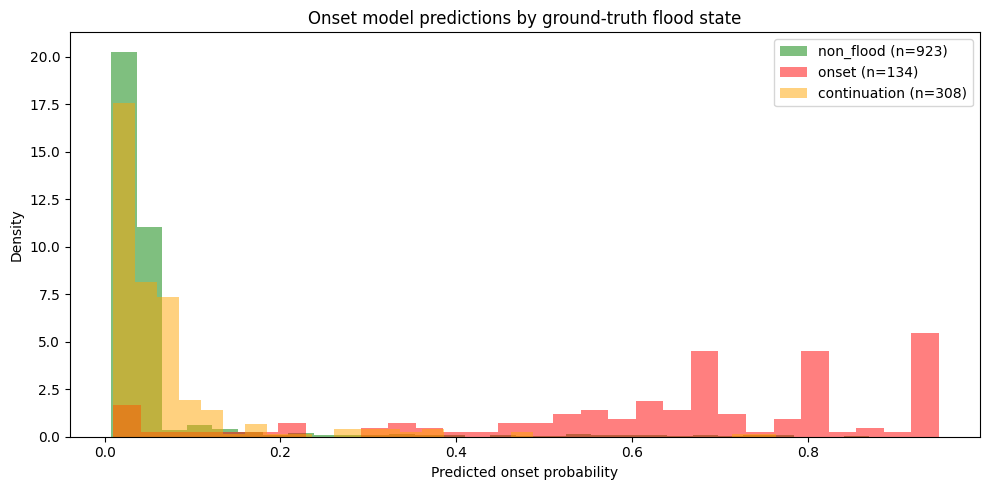

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
for state, color in zip(["non_flood", "onset", "continuation"],
                         ["green", "red", "orange"]):
    sub = df[df["flood_state"] == state]["onset_pred"].dropna()
    if len(sub) > 0:
        ax.hist(sub, bins=30, alpha=0.5, label=f"{state} (n={len(sub)})",
                color=color, density=True)
ax.set_xlabel("Predicted onset probability")
ax.set_ylabel("Density")
ax.set_title("Onset model predictions by ground-truth flood state")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/onset_predictions_by_state.png", dpi=80)
plt.show()
plt.close()

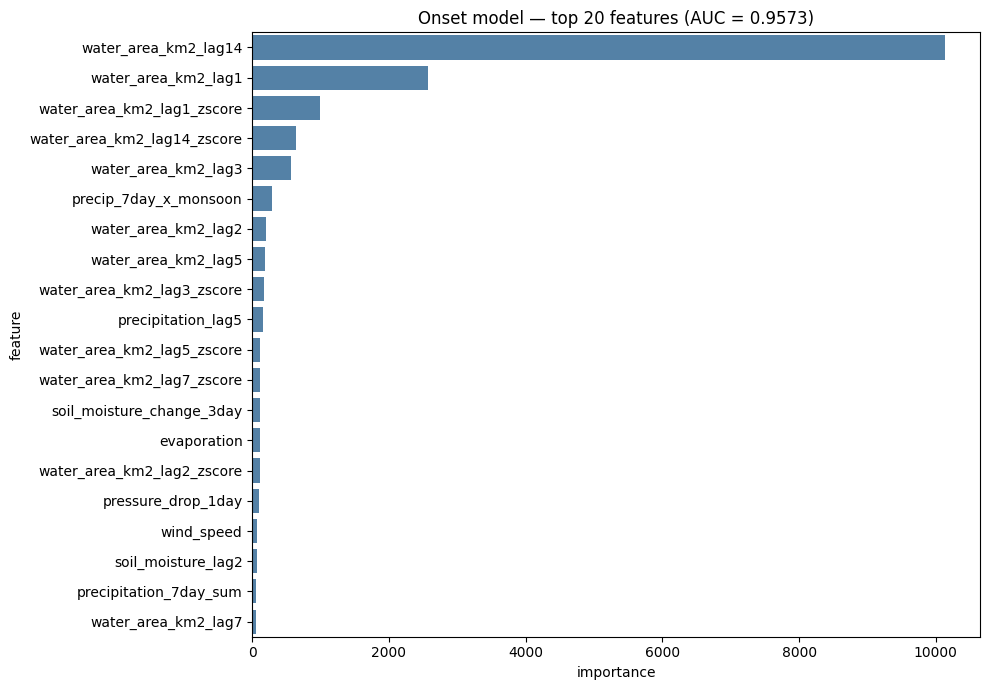

In [31]:
avg_imp = np.mean(fold_imp, axis=0)
imp_df = pd.DataFrame({"feature": feature_cols, "importance": avg_imp})
imp_df = imp_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=imp_df, x="importance", y="feature", color="steelblue")
plt.title(f"Onset model — top 20 features (AUC = {overall_auc:.4f})")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/onset_feature_importance.png", dpi=80)
plt.show()
plt.close()

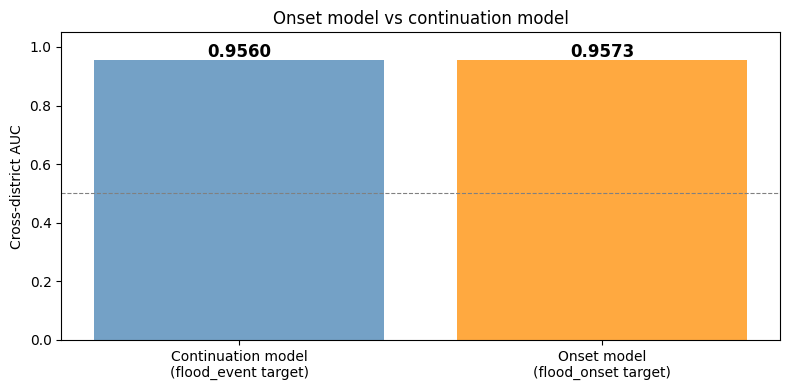

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Continuation model\n(flood_event target)", "Onset model\n(flood_onset target)"]
aucs   = [0.9560, overall_auc]
colors = ["steelblue", "darkorange"]
bars = ax.bar(labels, aucs, color=colors, alpha=0.75)
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{auc:.4f}", ha="center", fontsize=12, fontweight="bold")
ax.axhline(y=0.5, color="grey", linestyle="--", linewidth=0.8)
ax.set_ylabel("Cross-district AUC")
ax.set_title("Onset model vs continuation model")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/onset_vs_continuation.png", dpi=80)
plt.show()
plt.close()

In [33]:
np.save(f"{MODELS_DIR}/oof_preds_onset.npy", oof_preds)
imp_df.to_csv(f"{MODELS_DIR}/feature_importance_onset.csv", index=False)
for i, m in enumerate(models, start=1):
    m.save_model(f"{MODELS_DIR}/lgb_onset_fold{i}.txt")

print(f"Artifacts saved to {MODELS_DIR}/  and  {PLOTS_DIR}/")

Artifacts saved to onset_models/  and  onset_plots/
